In [1]:
import cfe

[09/22/2025 12:20:10] INFO                                                                                                                                                                              
                                  _____     _ _ ______    _       ______            _                                                                                                                   
                                 / ____|   | | |  ____|  | |     |  ____|          | |                                                                                                                  
                                | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __                                                                                               
                                | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__|                                                                                          

In [2]:
fadata = cfe.data.read_h5ad("../../tests/data/pancrease_scvelo_500_fadata.h5ad")
fadata.add_prior_information(start_cell="cell_000")

# method = cfe.method.FateMethod(method_name="ti_slingshot")
# method.infer_trajectory(fadata)

<Axes: title={'center': 'milestone'}, xlabel='X_umap1', ylabel='X_umap2'>

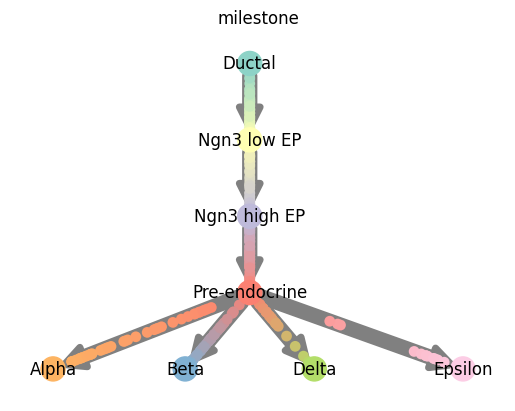

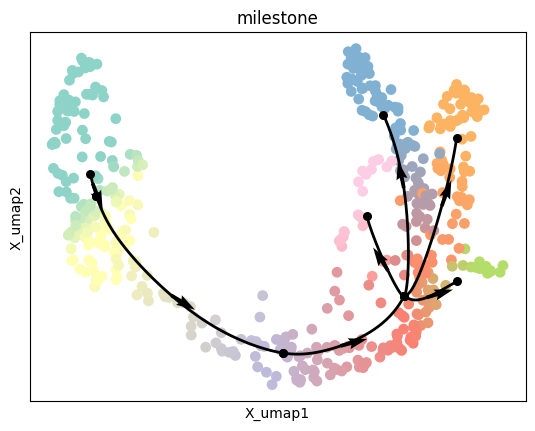

In [3]:
cfe.plot.plot_graph(fadata)
cfe.plot.plot_trajectory(fadata, color="milestone")

## Velocity

In [4]:
# import numpy as np
# import pandas as pd

# self = fadata
# basis=None
# model_name=None

# # 1,2 calc milestone positions in embedding space: refer to cfe.plot.project_waypoints
# # 1. extract trajectory and cell embedding
# milestone_wrapper = self.get_milestone_wrapper(model_name)
# if basis is None:
#     basis = self.prior_information.get("basis")
# cell_embedding = self.obsm[basis]
# cell_embedding_df = pd.DataFrame(cell_embedding, index=self.obs.index)

# milestone_network = milestone_wrapper.milestone_network
# progressions = milestone_wrapper.progressions
# milestone_percentages = milestone_wrapper.milestone_percentages

# # 2. merge and calc weighted avg milestone embedding
# merged_df = milestone_percentages.merge(cell_embedding_df, left_on="cell_id", right_index=True)
        
# def weighted_avg(group):
#     coords = group.iloc[:, -cell_embedding.shape[1]:]
#     weights = group["percentage"]
#     # if weights.sum() == 0:
#     #     return pd.Series(np.nan, index=coords.columns)
#     return (coords.multiply(weights, axis=0)).sum() / weights.sum()

# milestone_embedding = merged_df.groupby("milestone_id").apply(weighted_avg)

# # 3. calc pseudovelocity vectors for each cell
# # TODO: fix for divergence region
# edge_vectors = milestone_embedding.loc[milestone_network["to"]].values - milestone_embedding.loc[milestone_network["from"]].values
# edge_vectors_df = pd.DataFrame(edge_vectors, index=pd.MultiIndex.from_frame(milestone_network[["from", "to"]]))

# # Map each cell's progression to its corresponding edge vector
# prog_with_vectors = progressions.join(edge_vectors_df, on=["from", "to"])

# def weighted_avg_velocity(group):
#     # For each cell, calculate the weighted average of its associated edge vectors
#     # Extract vectors and weights
#     vectors = group.iloc[:, -cell_embedding.shape[1]:].values
#     weights = group["percentage"].values
#     # Calculate weighted average: sum(vector * weight) / sum(weights)
#     weighted_vectors = vectors * weights[:, np.newaxis]
#     sum_of_weights = weights.sum()
    
#     if sum_of_weights > 0:
#         return weighted_vectors.sum(axis=0) / sum_of_weights
#     else:
#         # Return a zero vector if weights sum to 0 to avoid division by zero
#         return np.zeros(cell_embedding.shape[1])

# # Group by cell_id and apply the weighted average calculation
# velocity_df = prog_with_vectors.groupby("cell_id").apply(weighted_avg_velocity)
# velocity_df = pd.DataFrame(velocity_df.to_list(), index=velocity_df.index)
# velocity_df = velocity_df.loc[self.obs.index]

# velocity_embedding = velocity_df.values
# self

# Note: add to FateAnnData
velocity = fadata.get_trajectory_pseudo_velocity()
fadata.obsm["velocity_umap"] = velocity

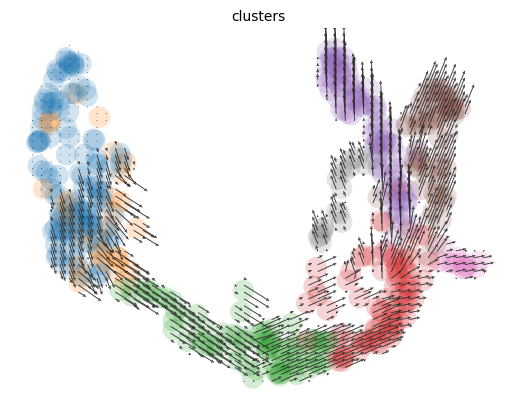

In [5]:
import scvelo as scv

scv.pl.velocity_embedding_grid(fadata, arrow_length=5)
# scv.pl.velocity_embedding_stream(fadata, color="milestone", legend_loc="")

## Velocity Metric

In [6]:
# pre-defined cluster pair
cluster_edges = {
    ("Ductal", "Ngn3 low EP"),
    ("Ngn3 low EP", "Ngn3 high EP"),
    ("Ngn3 high EP", "Pre-endocrine"),
    ("Pre-endocrine", "Alpha"),
    ("Pre-endocrine", "Beta"),
    ("Pre-endocrine", "Delta"),
    ("Pre-endocrine", "Epsilon"),
}

# prerprocess for neighbor
import scvelo as scv
scv.pp.filter_and_normalize(fadata, min_shared_counts=20, n_top_genes=2000)
scv.pp.moments(fadata, n_pcs=20, n_neighbors=10)

# velocity metric calculation
velocity_metric = cfe.metric.calculate_velocity_metrics(
    adata=fadata, 
    cluster_edges=cluster_edges,
    cluster="clusters",
    basis="X_umap",
    return_raw=False
)
velocity_metric

Filtered out 24737 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.
Extracted 2000 highly variable genes.
Logarithmized X.
computing neighbors
    finished (0:00:11) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


{'CBDir': 0.48900485719611675, 'ICVCoh': 0.9012366594348021}